# **Análisis Comparativo de las Fronteras**

Se comparan las tres series de fronteras (01 La Aurora, 07 Valle Nuevo, 09 San Cristóbal) en estacionalidad, tendencia de crecimiento, volatilidad e impacto de la pandemia. Las tres primeras métricas se calculan sobre 2009-2019 (sin distorsión pandémica); la última, sobre la caída 2019→2020. Medidas: ACF en el mes 12 (estacionalidad), % de crecimiento 2009-2019 (tendencia), coeficiente de variación (volatilidad) y % de caída 2019→2020 (pandemia).

## **Setup**

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import acf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "analisisComparativo" else Path.cwd()
RUTA_TRAIN = RAIZ / "datos" / "processed" / "entrenamiento.csv"

print("Setup completado")


Setup completado


## **Series y métricas comparativas**

Se calculan, para cada frontera, la ACF en el mes 12 (sobre la serie diferenciada), el % de crecimiento 2009-2019, el coeficiente de variación y el % de caída por la pandemia.

In [2]:
entrenamiento = pd.read_csv(RUTA_TRAIN, parse_dates=["Fecha"])
fronteras = ["01 La Aurora", "07 Valle Nuevo", "09 San Cristóbal"]

series = {}
for f in fronteras:
    x = entrenamiento[entrenamiento["Frontera"] == f].groupby("Fecha")["Viajero"].sum().asfreq("MS")
    series[f] = x.fillna(x.min())

def metricas_comparativas(x):
    pre = x[(x.index >= "2009-01-01") & (x.index < "2020-01-01")]
    acf_mes_12 = acf(pre.diff().dropna(), nlags=12)[12]
    anual = pre.groupby(pre.index.year).sum()
    crecimiento = (anual.loc[2019] / anual.loc[2009] - 1) * 100
    cv = pre.std() / pre.mean()
    caida = (1 - x[x.index.year == 2020].min() / x[x.index.year == 2019].mean()) * 100
    return {
        "ACF_mes_12": round(acf_mes_12, 2),
        "crecimiento_%": round(crecimiento, 0),
        "CV": round(cv, 2),
        "caida_pandemia_%": round(caida, 1),
    }

comparativa = pd.DataFrame({f: metricas_comparativas(series[f]) for f in fronteras}).T
display(comparativa)


,ACF_mes_12,crecimiento_%,CV,caida_pandemia_%
01 La Aurora,0.77,59.0,0.22,99.6
07 Valle Nuevo,0.49,152.0,0.40,99.9
09 San Cristóbal,0.35,238.0,0.52,100.0


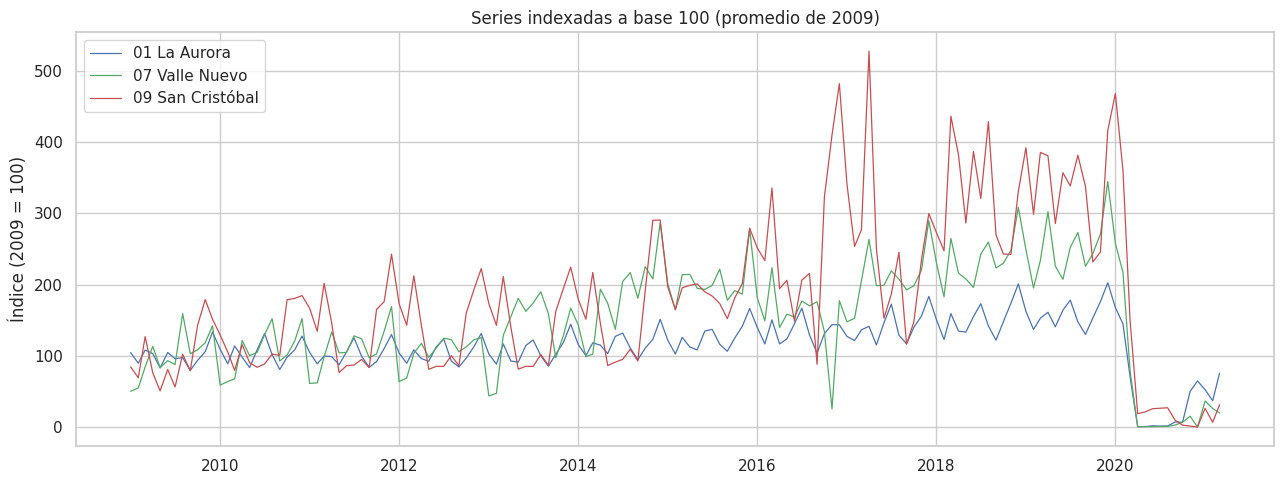

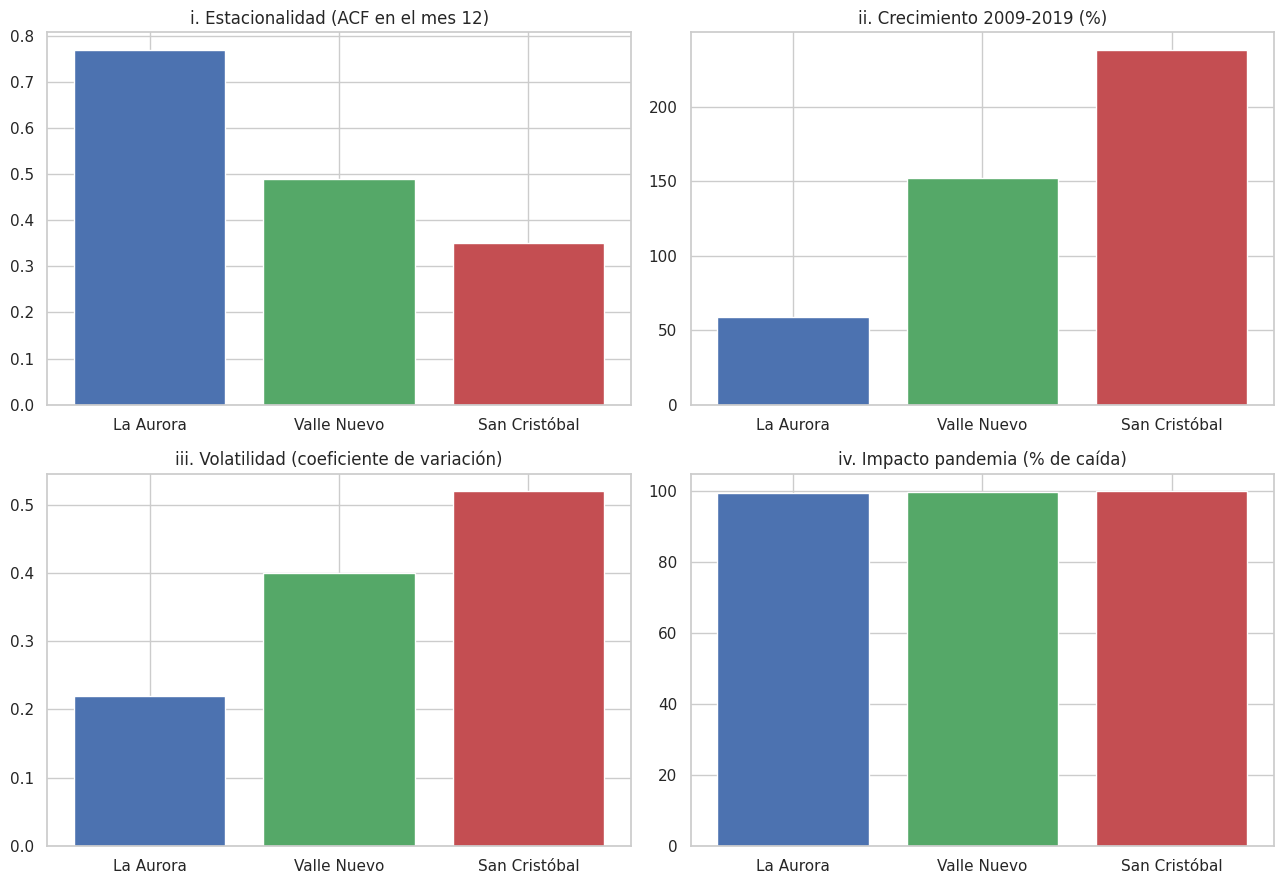

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
for f, color in zip(fronteras, ["#4C72B0", "#55A868", "#C44E52"]):
    x = series[f]
    ax.plot(x.index, x / x[x.index.year == 2009].mean() * 100, label=f, linewidth=0.9, color=color)
ax.set_title("Series indexadas a base 100 (promedio de 2009)")
ax.set_ylabel("Índice (2009 = 100)")
ax.legend()
plt.tight_layout()
plt.show()

etiquetas = ["La Aurora", "Valle Nuevo", "San Cristóbal"]
colores = ["#4C72B0", "#55A868", "#C44E52"]
paneles = [
    ("ACF_mes_12", "i. Estacionalidad (ACF en el mes 12)"),
    ("crecimiento_%", "ii. Crecimiento 2009-2019 (%)"),
    ("CV", "iii. Volatilidad (coeficiente de variación)"),
    ("caida_pandemia_%", "iv. Impacto pandemia (% de caída)"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, titulo) in zip(axes.flat, paneles):
    ax.bar(etiquetas, comparativa[col].values, color=colores)
    ax.set_title(titulo)
plt.tight_layout()
plt.show()


## **i. ¿Cuál presenta mayor estacionalidad?**

01 La Aurora (ACF=0.77), muy por encima de Valle Nuevo (0.49) y San Cristóbal (0.35). Tiene sentido: es el aeropuerto, y el turismo aéreo se concentra en temporadas específicas. Las fronteras terrestres reciben un flujo más constante (comercio, visitas familiares), lo que diluye el patrón estacional.

## **ii. ¿Cuál presenta mayor tendencia de crecimiento?**

09 San Cristóbal (238%), luego Valle Nuevo (152%) y La Aurora (59%). Se explica porque San Cristóbal parte de una base mucho menor (máximo mensual de 53 mil vs. más de 100 mil en las otras), por lo que el mismo incremento absoluto es un % de crecimiento mayor. En volumen absoluto, La Aurora sigue siendo la más grande.

## **iii. ¿Cuál presenta mayor volatilidad?**

09 San Cristóbal (CV=0.52), luego Valle Nuevo (0.40) y La Aurora (0.22). El orden coincide con el crecimiento: la frontera que más creció porcentualmente es también la más volátil, al pasar de un nivel bajo a uno mucho más alto en el mismo período.

## **iv. ¿Cuál fue la más afectada por la pandemia?**

Las tres casi se anulan: 99.6% (La Aurora), 99.9% (Valle Nuevo) y 100.0% (San Cristóbal). A diferencia de las regiones, aquí casi no hay diferencia entre fronteras: el cierre fue una decisión nacional única que afectó por igual la vía aérea y la terrestre.

## **En general: hallazgos útiles para INGUAT**

- La estacionalidad depende de la vía: la aérea (La Aurora) concentra el turismo en temporadas, la terrestre (Valle Nuevo, San Cristóbal) recibe un flujo más estable y menos "turístico". Las campañas estacionales deberían enfocarse en el segmento aéreo.
- El mayor crecimiento porcentual está en las fronteras terrestres con menor volumen, lo que sugiere oportunidad de inversión en esa infraestructura, hoy con menos atención que el aeropuerto.
- El cierre por pandemia fue prácticamente total y pareja en las tres fronteras, reflejo de una política nacional y no de diferencias propias de cada punto de ingreso; la recuperación pospandemia debería monitorearse por frontera.